# Online Food Delivery Analysis - EDA & Business Insights

- Customer & order behaviour
- Revenue & profit analysis
- Delivery performance
- Restaurant performance
- Operational insights (peak hours, payments, cancellations)



## 1. Setup: import libraries and load the cleaned data

In [2]:
import sys
print(sys.executable)

e:\Food_Delivery_Project2\.venv\Scripts\python.exe


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

df = pd.read_csv("../data/food_delivery_cleaned.csv", parse_dates=["Order_Date"])
print("Rows, Columns:", df.shape)
df.head()

Rows, Columns: (98986, 28)


,Order_ID,Customer_ID,Customer_Age,Customer_Gender,City,Area,Restaurant_ID,Restaurant_Name,Cuisine_Type,Order_Date,...,Delivery_Partner_ID,Delivery_Rating,Restaurant_Rating,Order_Day,Peak_Hour,Profit_Margin,Order_Month,Profit_Margin_Pct,Delivery_Performance,Customer_Age_Group
0,ORD000001,CUST6948,19.0,Male,Hyderabad,Central,RES936,Restaurant_29,Chinese,2024-10-20,...,DP563,5.0,4.4,Weekend,True,0.13,October,13.0,Slow,18-25
1,ORD000002,CUST6515,39.0,Female,Chennai,North,RES689,Restaurant_419,Chinese,2024-08-12,...,DP369,5.0,4.7,Weekday,True,0.48,August,48.0,Fast,36-45
2,ORD000003,CUST1765,39.0,Male,Delhi,South,RES723,Restaurant_244,Arabian,2024-12-08,...,DP580,4.0,4.9,Weekend,True,0.08,December,8.0,Slow,36-45
3,ORD000004,CUST2744,39.0,Male,Mumbai,Central,RES951,Restaurant_178,Chinese,2024-10-08,...,DP155,3.0,3.4,Weekday,False,0.04,October,4.0,Slow,36-45
4,ORD000005,CUST4389,57.0,Female,Chennai,South,RES419,Restaurant_262,Chinese,2024-02-04,...,DP728,2.0,4.4,Weekend,False,0.12,February,12.0,Moderate,46+


In [5]:
# Quick look at data types and confirm there are no missing values left
df.info()
print("\nMissing values per column:\n", df.isnull().sum().sum())

<class 'pandas.DataFrame'>
RangeIndex: 98986 entries, 0 to 98985
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Order_ID              98986 non-null  str           
 1   Customer_ID           98986 non-null  str           
 2   Customer_Age          98986 non-null  float64       
 3   Customer_Gender       98986 non-null  str           
 4   City                  98986 non-null  str           
 5   Area                  98986 non-null  str           
 6   Restaurant_ID         98986 non-null  str           
 7   Restaurant_Name       98986 non-null  str           
 8   Cuisine_Type          98986 non-null  str           
 9   Order_Date            98986 non-null  datetime64[us]
 10  Delivery_Time_Min     98986 non-null  float64       
 11  Distance_km           98986 non-null  float64       
 12  Order_Value           98986 non-null  float64       
 13  Discount_Applied      98986

## 2. Top-Level KPIs
These are the same numbers that will appear at the top of the Streamlit dashboard.

In [6]:
total_orders = len(df)
total_revenue = df["Final_Amount"].sum()
avg_order_value = df["Final_Amount"].mean()
avg_delivery_time = df["Delivery_Time_Min"].mean()
cancellation_rate = (df["Order_Status"] == "Cancelled").mean() * 100
avg_delivery_rating = df.loc[df["Order_Status"] == "Delivered", "Delivery_Rating"].mean()
avg_profit_margin = df["Profit_Margin_Pct"].mean()

print(f"Total Orders            : {total_orders:,}")
print(f"Total Revenue           : ₹{total_revenue:,.0f}")
print(f"Average Order Value     : ₹{avg_order_value:,.2f}")
print(f"Average Delivery Time   : {avg_delivery_time:.1f} minutes")
print(f"Cancellation Rate       : {cancellation_rate:.2f}%")
print(f"Average Delivery Rating : {avg_delivery_rating:.2f} / 5")
print(f"Average Profit Margin   : {avg_profit_margin:.2f}%")

Total Orders            : 98,986
Total Revenue           : ₹169,208,208
Average Order Value     : ₹1,709.42
Average Delivery Time   : 125.0 minutes
Cancellation Rate       : 15.04%
Average Delivery Rating : 2.99 / 5
Average Profit Margin   : 17.89%


## 3. Customer & Order Analysis

**Q: Who are the top-spending customers, and how does age affect order value?**

In [7]:
top_customers = (df.groupby("Customer_ID")["Final_Amount"]
                 .sum()
                 .sort_values(ascending=False)
                 .head(10))
top_customers

Customer_ID
CUST5267    51977.0
CUST1606    51371.0
CUST6706    47539.0
CUST6252    46025.0
CUST5534    45368.0
CUST1239    45233.0
CUST6457    44601.0
CUST1968    44381.0
CUST4431    44335.0
CUST8819    43963.0
Name: Final_Amount, dtype: float64

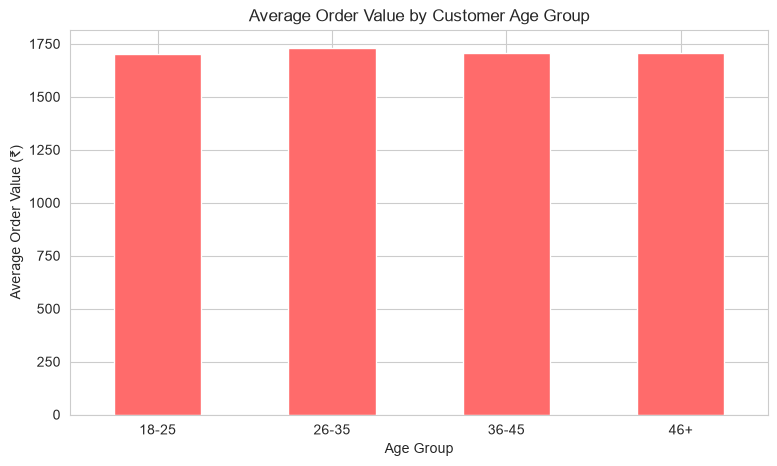

In [8]:
age_group_value = df.groupby("Customer_Age_Group", observed=True)["Final_Amount"].mean().sort_index()

age_group_value.plot(kind="bar", color="#FF6B6B")
plt.title("Average Order Value by Customer Age Group")
plt.ylabel("Average Order Value (₹)")
plt.xlabel("Age Group")
plt.xticks(rotation=0)
plt.show()

**Q: Do people order more on weekends or weekdays?**

In [9]:
weekday_weekend = df.groupby("Order_Day").agg(
    Total_Orders=("Order_ID", "count"),
    Avg_Order_Value=("Final_Amount", "mean")
)
weekday_weekend

,Total_Orders,Avg_Order_Value
Order_Day,,
Weekday,70618,1712.251367
Weekend,28368,1702.356211


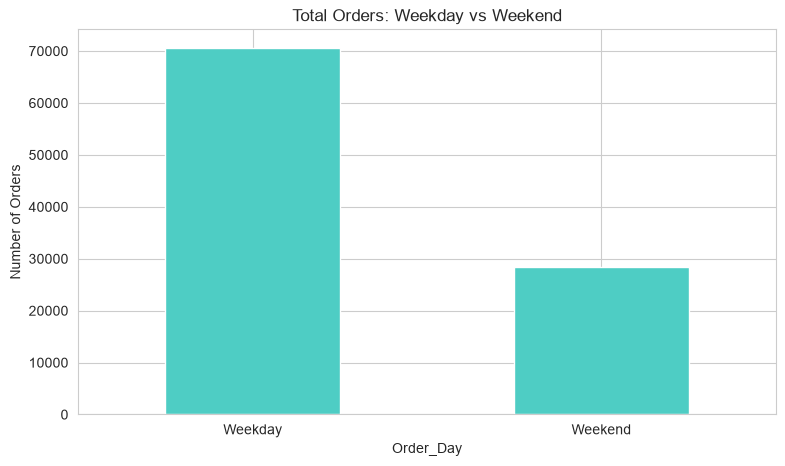

In [10]:
weekday_weekend["Total_Orders"].plot(kind="bar", color="#4ECDC4")
plt.title("Total Orders: Weekday vs Weekend")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

## 4. Revenue & Profit Analysis

**Q: How does revenue trend across months, and which cities/cuisines earn the most?**

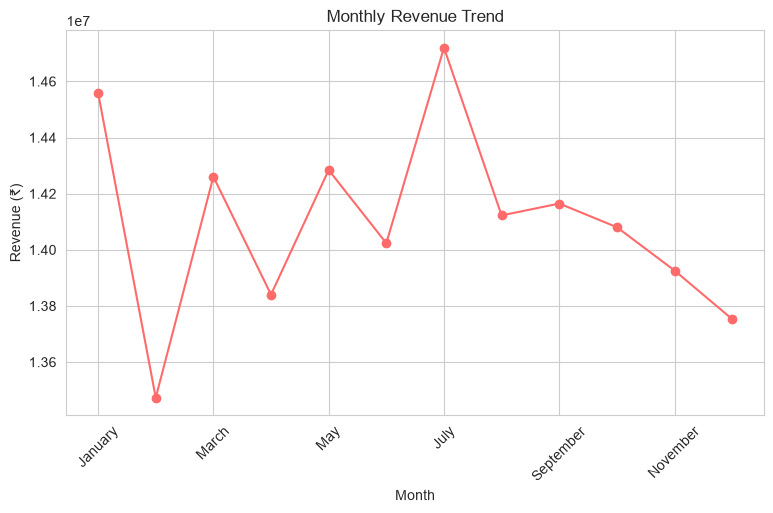

In [11]:
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
monthly_revenue = (df.groupby("Order_Month")["Final_Amount"]
                   .sum()
                   .reindex(month_order)
                   .dropna())

monthly_revenue.plot(kind="line", marker="o", color="#FF6B6B")
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue (₹)")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.show()

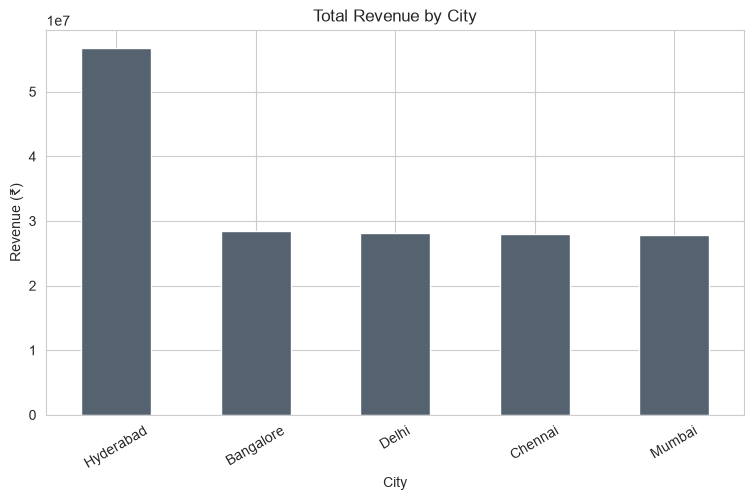

In [12]:
city_revenue = df.groupby("City")["Final_Amount"].sum().sort_values(ascending=False)

city_revenue.plot(kind="bar", color="#556270")
plt.title("Total Revenue by City")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=30)
plt.show()

In [13]:
cuisine_revenue = df.groupby("Cuisine_Type")["Final_Amount"].sum().sort_values(ascending=False)
cuisine_revenue

Cuisine_Type
Indian     57115407.0
Chinese    28207057.0
Mexican    28165897.0
Italian    27860580.0
Arabian    27859267.0
Name: Final_Amount, dtype: float64

**Q: Do bigger discounts hurt profit margin?**

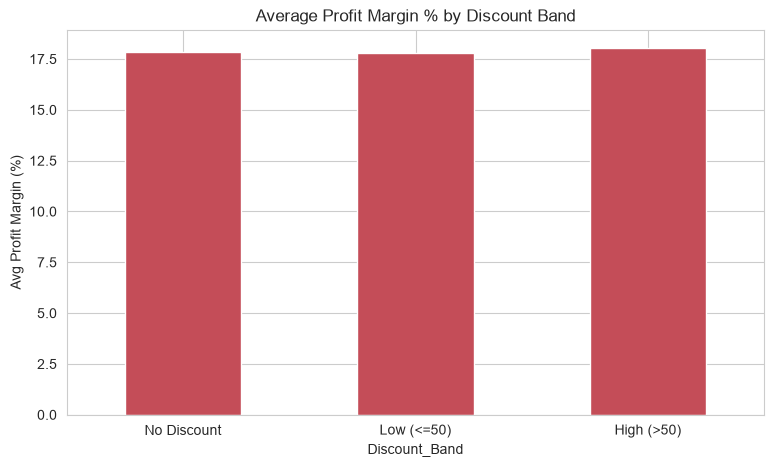

In [14]:
df["Discount_Band"] = pd.cut(
    df["Discount_Applied"],
    bins=[-1, 0, 50, df["Discount_Applied"].max()],
    labels=["No Discount", "Low (<=50)", "High (>50)"]
)
discount_vs_margin = df.groupby("Discount_Band", observed=True)["Profit_Margin_Pct"].mean()

discount_vs_margin.plot(kind="bar", color="#C44D58")
plt.title("Average Profit Margin % by Discount Band")
plt.ylabel("Avg Profit Margin (%)")
plt.xticks(rotation=0)
plt.show()

## 5. Delivery Performance

**Q: Which cities have the slowest deliveries, and how does distance affect delivery time?**

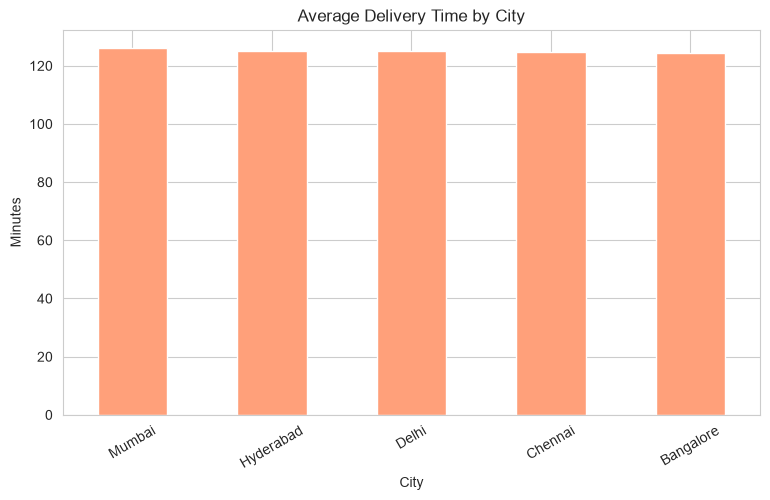

In [15]:
city_delivery_time = df.groupby("City")["Delivery_Time_Min"].mean().sort_values(ascending=False)

city_delivery_time.plot(kind="bar", color="#FFA07A")
plt.title("Average Delivery Time by City")
plt.ylabel("Minutes")
plt.xticks(rotation=30)
plt.show()

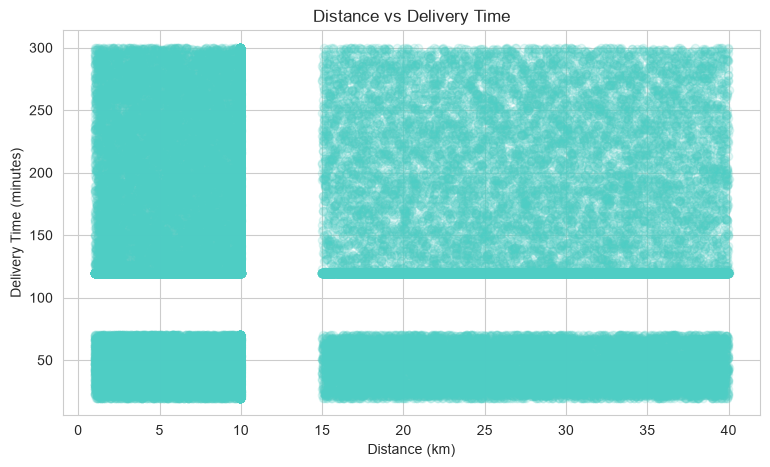

Correlation between distance and delivery time: 0.002


In [16]:
plt.scatter(df["Distance_km"], df["Delivery_Time_Min"], alpha=0.15, color="#4ECDC4")
plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (minutes)")
plt.show()

print("Correlation between distance and delivery time:",
      round(df["Distance_km"].corr(df["Delivery_Time_Min"]), 3))

**Q: Does a faster delivery mean a happier customer?**

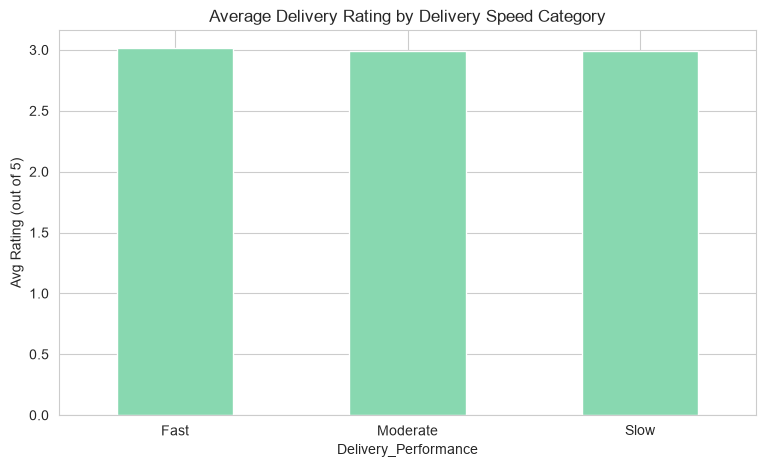

In [17]:
delivered = df[df["Order_Status"] == "Delivered"]
rating_by_perf = delivered.groupby("Delivery_Performance")["Delivery_Rating"].mean().reindex(
    ["Fast", "Moderate", "Slow"])

rating_by_perf.plot(kind="bar", color="#88D8B0")
plt.title("Average Delivery Rating by Delivery Speed Category")
plt.ylabel("Avg Rating (out of 5)")
plt.xticks(rotation=0)
plt.show()

## 6. Restaurant Performance

**Q: Which restaurants perform best, and which cancel the most orders?**

In [18]:
restaurant_orders = df.groupby("Restaurant_Name").size()
qualified_restaurants = restaurant_orders[restaurant_orders >= 20].index

top_rated = (df[df["Restaurant_Name"].isin(qualified_restaurants)]
             .groupby("Restaurant_Name")["Restaurant_Rating"]
             .mean()
             .sort_values(ascending=False)
             .head(10))
top_rated

Restaurant_Name
Restaurant_101    4.329944
Restaurant_162    4.317222
Restaurant_1      4.311458
Restaurant_496    4.302985
Restaurant_481    4.301587
Restaurant_209    4.300478
Restaurant_352    4.300000
Restaurant_355    4.298324
Restaurant_403    4.297268
Restaurant_119    4.295402
Name: Restaurant_Rating, dtype: float64

In [19]:
cancel_rate = (df[df["Restaurant_Name"].isin(qualified_restaurants)]
               .groupby("Restaurant_Name")["Order_Status"]
               .apply(lambda s: (s == "Cancelled").mean() * 100)
               .sort_values(ascending=False)
               .head(10))
cancel_rate

Restaurant_Name
Restaurant_202    22.000000
Restaurant_477    21.839080
Restaurant_391    21.649485
Restaurant_390    21.608040
Restaurant_299    21.354167
Restaurant_113    21.182266
Restaurant_455    21.111111
Restaurant_373    21.052632
Restaurant_437    20.975610
Restaurant_361    20.903955
Name: Order_Status, dtype: float64

In [20]:
cuisine_perf = df.groupby("Cuisine_Type").agg(
    Avg_Rating=("Restaurant_Rating", "mean"),
    Total_Revenue=("Final_Amount", "sum"),
    Total_Orders=("Order_ID", "count")
).sort_values("Total_Revenue", ascending=False)
cuisine_perf

,Avg_Rating,Total_Revenue,Total_Orders
Cuisine_Type,,,
Indian,4.200304,57115407.0,33224
Chinese,4.190980,28207057.0,16486
Mexican,4.195255,28165897.0,16419
Italian,4.210347,27860580.0,16382
Arabian,4.202252,27859267.0,16475


## 7. Operational Insights

**Q: When is demand highest, how do customers pay, and why do orders get cancelled?**

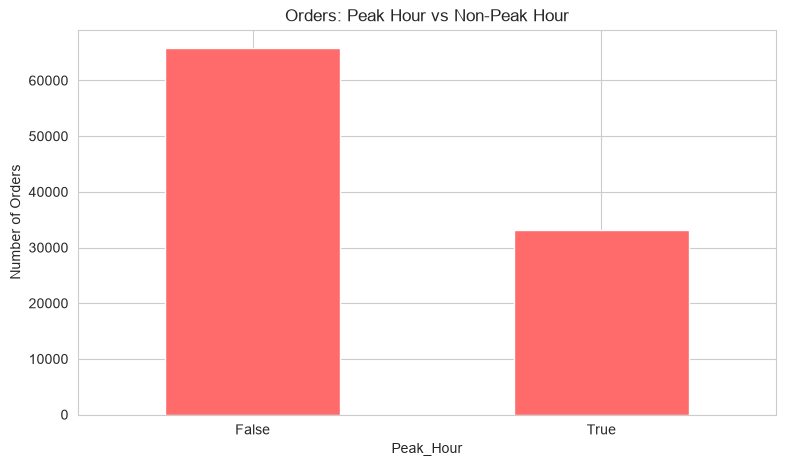

In [21]:
peak_hour_demand = df["Peak_Hour"].value_counts()

peak_hour_demand.plot(kind="bar", color="#FF6B6B")
plt.title("Orders: Peak Hour vs Non-Peak Hour")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

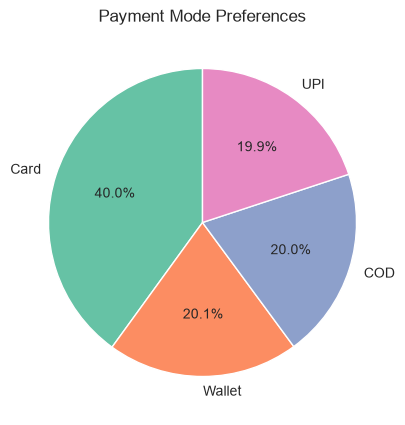

In [22]:
payment_counts = df["Payment_Mode"].value_counts()

payment_counts.plot(kind="pie", autopct="%1.1f%%", startangle=90,
                     colors=sns.color_palette("Set2"))
plt.title("Payment Mode Preferences")
plt.ylabel("")
plt.show()

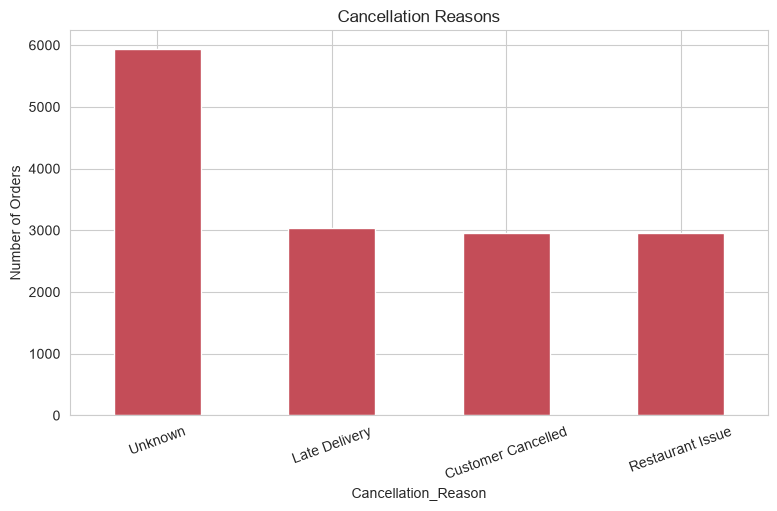

In [23]:
cancel_reasons = df.loc[df["Order_Status"] == "Cancelled", "Cancellation_Reason"].value_counts()

cancel_reasons.plot(kind="bar", color="#C44D58")
plt.title("Cancellation Reasons")
plt.ylabel("Number of Orders")
plt.xticks(rotation=20)
plt.show()

## 8. Correlation Between Numeric Features

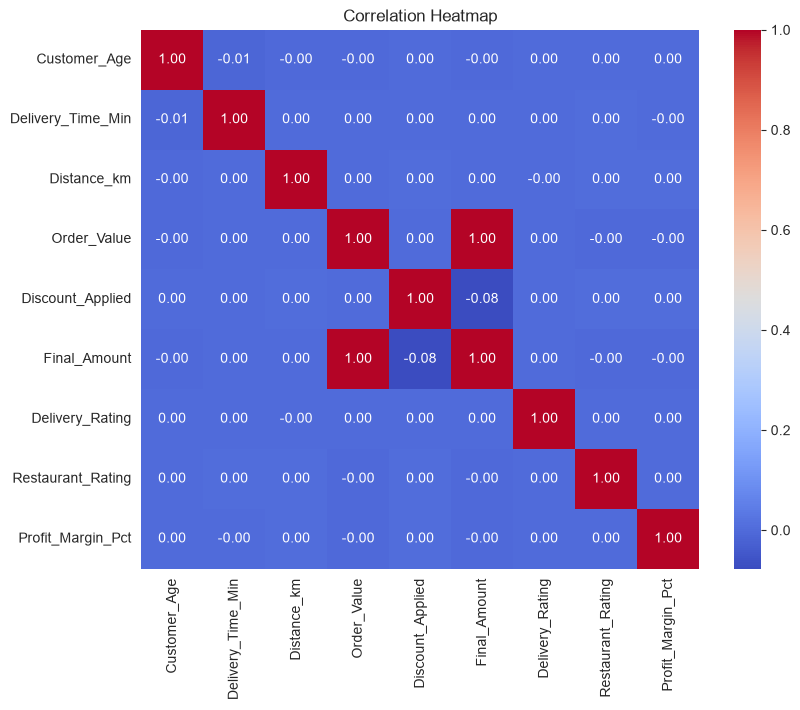

In [ ]:
numeric_cols = ["Customer_Age", "Delivery_Time_Min", "Distance_km", "Order_Value",
                "Discount_Applied", "Final_Amount", "Delivery_Rating",
                "Restaurant_Rating", "Profit_Margin_Pct"]

plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 9. Summary of Key Insights

- **Revenue**: Hyderabad is the highest-revenue city, and Indian cuisine
  is the highest-revenue cuisine type overall.
- **Delivery**: Mumbai has the slowest average delivery time of the five
  cities. Distance has almost no correlation with delivery time in this
  dataset (correlation ≈ 0.00).
- **Delivery speed vs rating**: Interestingly, average delivery rating
  is nearly identical across Fast, Moderate and Slow orders (~3.0 for
  all three) — customers in this dataset don't appear to rate faster
  deliveries noticeably higher.
- **Cancellations**: The overall cancellation rate is about **15%**.
  Among *known* reasons, "Late Delivery", "Customer Cancelled" and

  "Restaurant Issue" are roughly equally common. About 40% of cancelled
  orders have no reason logged at all ("Unknown") — worth flagging as
  a data-collection gap for the business to fix going forward.
- **Customers**: The 26-35 age group places the highest-value orders
  on average.

### Business Recommendations
1. Investigate why Mumbai's delivery times lag other cities — since
   distance isn't the driver here, look at restaurant prep time and
   delivery-partner availability instead.
2. Fix the cancellation-reason logging gap (~40% "Unknown") so the
   business can actually act on the real causes of cancellations.
3. Review the small number of restaurants with cancellation rates far
   above the ~15% average.
